In [14]:
import duckdb
import pandas as pd

con = duckdb.connect()
con.execute("INSTALL sqlite; LOAD sqlite;")
con.execute("ATTACH '../data/Chinook_Sqlite.sqlite' AS chinook (TYPE sqlite);")

## Consulta 1: Total de clientes por país

In [16]:
con.execute("""
    SELECT Country, COUNT(*) AS total_clientes
    FROM chinook.Customer
    GROUP BY Country
    ORDER BY total_clientes DESC
""").df()

,Country,total_clientes
0,USA,13
1,Canada,8
2,Brazil,5
3,France,5
4,Germany,4
5,United Kingdom,3
6,Czech Republic,2
7,India,2
8,Portugal,2
9,Hungary,1


## Consulta 2: Top 10 facturas por importe

In [15]:
con.execute("""
    SELECT InvoiceId, CustomerId, Total
    FROM chinook.Invoice
    ORDER BY Total DESC
    LIMIT 10
""").df()

,InvoiceId,CustomerId,Total
0,404,6,25.86
1,299,26,23.86
2,96,45,21.86
3,194,46,21.86
4,201,25,18.86
5,89,7,18.86
6,88,57,17.91
7,306,5,16.86
8,313,43,16.86
9,103,24,15.86


## Consulta 3: Ingresos totales por país (JOIN)

In [17]:
con.execute("""
    SELECT c.Country, ROUND(SUM(i.Total), 2) AS ingresos_totales
    FROM chinook.Customer c
    JOIN chinook.Invoice i ON c.CustomerId = i.CustomerId
    GROUP BY c.Country
    ORDER BY ingresos_totales DESC
""").df()

,Country,ingresos_totales
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


## Consulta 4: Top 10 artistas por ingresos generados (JOIN de 4 tablas)

In [18]:
con.execute("""
    SELECT ar.Name AS artista, ROUND(SUM(ii.UnitPrice * ii.Quantity), 2) AS ingresos
    FROM chinook.InvoiceLine ii
    JOIN chinook.Track t ON ii.TrackId = t.TrackId
    JOIN chinook.Album al ON t.AlbumId = al.AlbumId
    JOIN chinook.Artist ar ON al.ArtistId = ar.ArtistId
    GROUP BY ar.Name
    ORDER BY ingresos DESC
    LIMIT 10
""").df()

,artista,ingresos
0,Iron Maiden,138.60
1,U2,105.93
2,Metallica,90.09
3,Led Zeppelin,86.13
4,Lost,81.59
5,The Office,49.75
6,Os Paralamas Do Sucesso,44.55
7,Deep Purple,43.56
8,Faith No More,41.58
9,Eric Clapton,39.60


## Consulta 5: Clientes con gasto por encima de la media (subconsulta)

In [19]:
con.execute("""
    SELECT CustomerId, ROUND(SUM(Total), 2) AS gasto_total
    FROM chinook.Invoice
    GROUP BY CustomerId
    HAVING SUM(Total) > (
        SELECT AVG(gasto_por_cliente)
        FROM (
            SELECT SUM(Total) AS gasto_por_cliente
            FROM chinook.Invoice
            GROUP BY CustomerId
        )
    )
    ORDER BY gasto_total DESC
""").df()

,CustomerId,gasto_total
0,6,49.62
1,26,47.62
2,57,46.62
3,45,45.62
4,46,45.62
5,28,43.62
6,24,43.62
7,37,43.62
8,7,42.62
9,25,42.62


## Consulta 6: Canciones más caras que el precio medio de su álbum

In [20]:
con.execute("""
    SELECT t.Name AS cancion, t.AlbumId, t.UnitPrice
    FROM chinook.Track t
    WHERE t.UnitPrice > (
        SELECT AVG(UnitPrice)
        FROM chinook.Track
        WHERE AlbumId = t.AlbumId
    )
    LIMIT 15
""").df()

,cancion,AlbumId,UnitPrice
0,Fast As a Shark,3,0.99
1,Restless and Wild,3,0.99
2,Princess of the Dawn,3,0.99
3,Sozinho (Hitmakers Classic Mix),22,0.99
4,Sozinho (Hitmakers Classic Radio Edit),22,0.99
5,Sozinho (Caêdrum 'n' Bass),22,0.99
6,Carolina,23,0.99
7,Essa Moça Ta Diferente,23,0.99
8,Vai Passar,23,0.99
9,Samba De Orly,23,0.99


## Consulta 8: Ingresos mensuales acumulados (CTE + window function)

In [21]:
con.execute("""
    WITH ingresos_mes AS (
        SELECT DATE_TRUNC('month', InvoiceDate) AS mes, SUM(Total) AS ingresos
        FROM chinook.Invoice
        GROUP BY mes
    )
    SELECT mes, ingresos,
           SUM(ingresos) OVER (ORDER BY mes) AS ingresos_acumulados
    FROM ingresos_mes
    ORDER BY mes
""").df()

,mes,ingresos,ingresos_acumulados
0,2021-01-01,35.64,35.64
1,2021-02-01,37.62,73.26
2,2021-03-01,37.62,110.88
3,2021-04-01,37.62,148.50
4,2021-05-01,37.62,186.12
5,2021-06-01,37.62,223.74
6,2021-07-01,37.62,261.36
7,2021-08-01,37.62,298.98
8,2021-09-01,37.62,336.60
9,2021-10-01,37.62,374.22


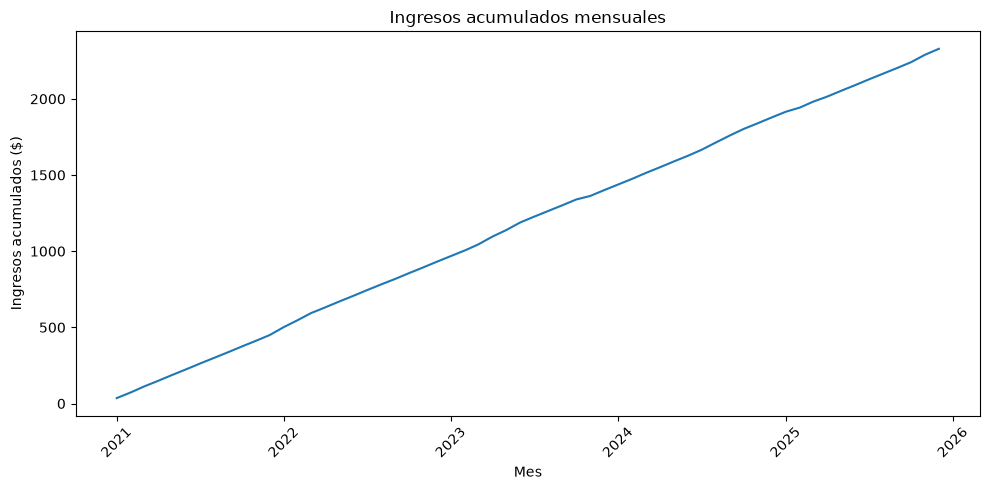

In [22]:
df = con.execute("""
    WITH ingresos_mes AS (
        SELECT DATE_TRUNC('month', InvoiceDate) AS mes, SUM(Total) AS ingresos
        FROM chinook.Invoice
        GROUP BY mes
    )
    SELECT mes, SUM(ingresos) OVER (ORDER BY mes) AS ingresos_acumulados
    FROM ingresos_mes
    ORDER BY mes
""").df()

import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df['mes'], df['ingresos_acumulados'])
plt.title('Ingresos acumulados mensuales')
plt.xlabel('Mes')
plt.ylabel('Ingresos acumulados ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/ingresos_acumulados.png')
plt.show()